## 📱 Data Cleaning with Google Play Store Dataset
This is a good beginner-friendly Data Analytics portfolio project. We can build it step-by-step in Google Colab, just like your Flight Price project.
Project Title
Google Play Store Data Cleaning & Analysis Using Python
🎯 Project Objective
Clean and preprocess the Google Play Store dataset by identifying and handling:
- Missing values
- Duplicate records
- Incorrect data types
- Invalid values
- Inconsistent formatting
- Duplicate applications
- Numerical columns stored as text
Then prepare a clean dataset for further EDA and visualization.

## Step 1 — Import Libraries & Load Dataset
If your file is named googleplaystore.csv, use:

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

%matplotlib inline
sns.set_style("whitegrid")

Load the CSV

In [6]:
df = pd.read_csv("/content/googleplaystore.csv")

Check the last 5 rows

In [7]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


Check dataset size

In [8]:
df.shape

(10841, 13)

Check column names

In [9]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

Check data types

In [10]:
df.dtypes

,0
App,object
Category,object
Rating,float64
Reviews,object
Size,object
Installs,object
Type,object
Price,object
Content Rating,object
Genres,object


Basic information

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


## Step 2 — Missing Values & Duplicate Analysis 🔍
Now we will only identify problems in the Google Play Store dataset. Don't remove or modify anything yet.
## 1. Check missing values

In [12]:
df.isnull().sum()

,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


Check duplicate rows

In [13]:
df.duplicated().sum()

np.int64(483)

Overall summary

In [14]:
print("Total Rows:", len(df))
print("Total Columns:", len(df.columns))
print("Total Missing Values:", df.isnull().sum().sum())
print("Total Duplicate Rows:", df.duplicated().sum())

Total Rows: 10841
Total Columns: 13
Total Missing Values: 1487
Total Duplicate Rows: 483


## Step 3 — Data Cleaning: Handle Missing Values & Duplicates 🧹
Now we will clean the problems identified in Step 2.
## 1. Check duplicate apps
Before removing duplicates, check how many records each app has:

In [15]:
df["App"].value_counts()

,count
App,
ROBLOX,9
"CBS Sports App - Scores, News, Stats & Watch Live",8
8 Ball Pool,7
Candy Crush Saga,7
ESPN,7
...,...
Remote For ATT U-verse TV - NOW FREE,1
Pocket U ASW,1
V LIVE - Star Live App,1


# 2. Remove duplicate app records
Keep the first record for each app:

In [16]:
df = df.drop_duplicates(subset="App", keep="first")

Check again:

In [17]:
df["App"].duplicated().sum()

np.int64(0)

# 3. Check missing values again

In [18]:
df.isnull().sum()

,0
App,0
Category,0
Rating,1463
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


For this dataset, important missing values commonly occur in columns such as:
- Rating
- Type
- Content Rating
- Current Ver
- Android Ver
## 4. Handle Rating
Rating is numerical, so replace missing ratings with the median:

In [19]:
df["Rating"] = df["Rating"].fillna(df["Rating"].median())

check:

In [20]:
df["Rating"].isnull().sum()

np.int64(0)

#  5. Handle categorical missing values

For categorical columns, use the mode:

In [21]:
categorical_columns = [
    "Type",
    "Content Rating",
    "Current Ver",
    "Android Ver"
]

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

Check all missing values:

In [22]:
df.isnull().sum()

,0
App,0
Category,0
Rating,0
Reviews,0
Size,0
Installs,0
Type,0
Price,0
Content Rating,0
Genres,0


## 6. Final cleaning check

In [23]:
print("Rows after cleaning:", df.shape[0])
print("Columns after cleaning:", df.shape[1])
print("Total missing values:", df.isnull().sum().sum())
print("Total duplicate rows:", df.duplicated().sum())

Rows after cleaning: 9660
Columns after cleaning: 13
Total missing values: 0
Total duplicate rows: 0


### Step 7 — Clean Size
The Size column contains values such as:
19M
14M
8.7M
1.5k
Varies with device

Create a new column in MB:

In [24]:
def convert_size(size):
    if isinstance(size, str):
        if size.endswith("M"):
            return float(size.replace("M", ""))
        elif size.endswith("k"):
            return float(size.replace("k", "")) / 1024
    return np.nan

In [25]:
df["Size_MB"] = df["Size"].apply(convert_size)

check:

In [26]:
df[["Size", "Size_MB"]].head(10)

,Size,Size_MB
0,19M,19.0
1,14M,14.0
2,8.7M,8.7
3,25M,25.0
4,2.8M,2.8
5,5.6M,5.6
6,19M,19.0
7,29M,29.0
8,33M,33.0
9,3.1M,3.1


## Step 8 — Clean Installs
Remove commas and +.

In [27]:
df["Installs"] = (
    df["Installs"]
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)

Convert to numeric

In [28]:
df["Installs"] = pd.to_numeric(
    df["Installs"],
    errors="coerce"
)

check:

In [29]:
df["Installs"].head()

,Installs
0,10000.0
1,500000.0
2,5000000.0
3,50000000.0
4,100000.0


## Step 9 — Clean Price
Remove $:

In [30]:
df["Price"] = (
    df["Price"]
    .str.replace("$", "", regex=False)
)

Convrt to numeric

In [31]:
df["Price"] = pd.to_numeric(
    df["Price"],
    errors="coerce"
)

Check:

In [32]:
df["Price"].head()

,Price
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


## Step 10 — Clean Last Updated Date
Convert Last Updated to datetime:

In [33]:
df["Last Updated"] = pd.to_datetime(
    df["Last Updated"],
    errors="coerce"
)

Check:

In [34]:
df["Last Updated"].dtype

dtype('<M8[ns]')

## Step 11 — Check Invalid Values
Rating

In [35]:
df["Rating"].describe()

,Rating
count,9660.000000
mean,4.193975
std,0.518732
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


Rating should normally be between 0 and 5.

In [36]:
df[df["Rating"] > 5]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",NaN,0,NaN,Everyone,"February 11, 2018",NaT,4.0 and up,4.1 and up,NaN


Reviews

In [42]:
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')
df[df["Reviews"] < 0]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB


installs

In [43]:
df[df["Installs"] < 0]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB


price

In [44]:
df[df["Price"] < 0]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB


## Step 12 — Check Categorical Values
App categories

In [45]:
df["Category"].value_counts()

,count
Category,
FAMILY,1832
GAME,959
TOOLS,827
BUSINESS,420
MEDICAL,395
PERSONALIZATION,376
PRODUCTIVITY,374
LIFESTYLE,369
FINANCE,345


App type

In [46]:
df["Type"].value_counts()

,count
Type,
Free,8903
Paid,756
0,1


Content ratings

In [47]:
df["Content Rating"].value_counts()

,count
Content Rating,
Everyone,7904
Teen,1036
Mature 17+,393
Everyone 10+,322
Adults only 18+,3
Unrated,2


Genres

In [48]:
df["Genres"].value_counts().head(20)

,count
Genres,
Tools,826
Entertainment,561
Education,510
Business,420
Medical,395
Personalization,376
Productivity,374
Lifestyle,368
Finance,345


## Step 13 — Check Data Consistency
Check column values:

In [49]:
for column in ["Category", "Type", "Content Rating"]:
    print("\n", column)
    print(df[column].unique())


 Category
['ART_AND_DESIGN' 'AUTO_AND_VEHICLES' 'BEAUTY' 'BOOKS_AND_REFERENCE'
 'BUSINESS' 'COMICS' 'COMMUNICATION' 'DATING' 'EDUCATION' 'ENTERTAINMENT'
 'EVENTS' 'FINANCE' 'FOOD_AND_DRINK' 'HEALTH_AND_FITNESS' 'HOUSE_AND_HOME'
 'LIBRARIES_AND_DEMO' 'LIFESTYLE' 'GAME' 'FAMILY' 'MEDICAL' 'SOCIAL'
 'SHOPPING' 'PHOTOGRAPHY' 'SPORTS' 'TRAVEL_AND_LOCAL' 'TOOLS'
 'PERSONALIZATION' 'PRODUCTIVITY' 'PARENTING' 'WEATHER' 'VIDEO_PLAYERS'
 'NEWS_AND_MAGAZINES' 'MAPS_AND_NAVIGATION' '1.9']

 Type
['Free' 'Paid' '0']

 Content Rating
['Everyone' 'Teen' 'Everyone 10+' 'Mature 17+' 'Adults only 18+' 'Unrated']


Check whitespace in column names:

In [50]:
df.columns = df.columns.str.strip()

Check whitespace in text columns:

In [51]:
text_columns = df.select_dtypes(include="object").columns

for column in text_columns:
    df[column] = df[column].str.strip()

Step 14 — Create Useful Features

Updated Year

In [52]:
df["Updated_Year"] = df["Last Updated"].dt.year

Updated month

In [53]:
df["Updated_Month"] = df["Last Updated"].dt.month

check:


In [54]:
df[[
    "Last Updated",
    "Updated_Year",
    "Updated_Month"
]].head()

,Last Updated,Updated_Year,Updated_Month
0,2018-01-07,2018.0,1.0
1,2018-01-15,2018.0,1.0
2,2018-08-01,2018.0,8.0
3,2018-06-08,2018.0,6.0
4,2018-06-20,2018.0,6.0


## Step 15 — Final Missing-Value Check

In [55]:
df.isnull().sum()

,0
App,0
Category,0
Rating,0
Reviews,1
Size,0
Installs,1
Type,0
Price,1
Content Rating,0
Genres,0


Total

In [56]:
print(
    "Total Missing Values:",
    df.isnull().sum().sum()
)

Total Missing Values: 1234


## Step 16 — Final Duplicate Check

In [57]:
print(
    "Total Duplicate Rows:",
    df.duplicated().sum()
)

Total Duplicate Rows: 0


In [58]:
print(
    "Duplicate Apps:",
    df["App"].duplicated().sum()
)

Duplicate Apps: 0


## Step 17 — Final Data Types

In [59]:
df.dtypes

,0
App,object
Category,object
Rating,float64
Reviews,float64
Size,object
Installs,float64
Type,object
Price,float64
Content Rating,object
Genres,object


## Step 18 — Final Dataset Information

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9660 entries, 0 to 10840
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             9660 non-null   object        
 1   Category        9660 non-null   object        
 2   Rating          9660 non-null   float64       
 3   Reviews         9659 non-null   float64       
 4   Size            9660 non-null   object        
 5   Installs        9659 non-null   float64       
 6   Type            9660 non-null   object        
 7   Price           9659 non-null   float64       
 8   Content Rating  9660 non-null   object        
 9   Genres          9660 non-null   object        
 10  Last Updated    9659 non-null   datetime64[ns]
 11  Current Ver     9660 non-null   object        
 12  Android Ver     9660 non-null   object        
 13  Size_MB         8432 non-null   float64       
 14  Updated_Year    9659 non-null   float64       
 15  Updated_

In [62]:
df.shape

(9660, 16)

In [63]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB,Updated_Year,Updated_Month
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19M,10000.0,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,19.0,2018.0,1.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14M,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,14.0,2018.0,1.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7M,5000000.0,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,8.7,2018.0,8.0
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25M,50000000.0,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,25.0,2018.0,6.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8M,100000.0,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,2.8,2018.0,6.0


## Step 20 — Basic EDA
After cleaning, you can start analysis.

## Top 10 categories

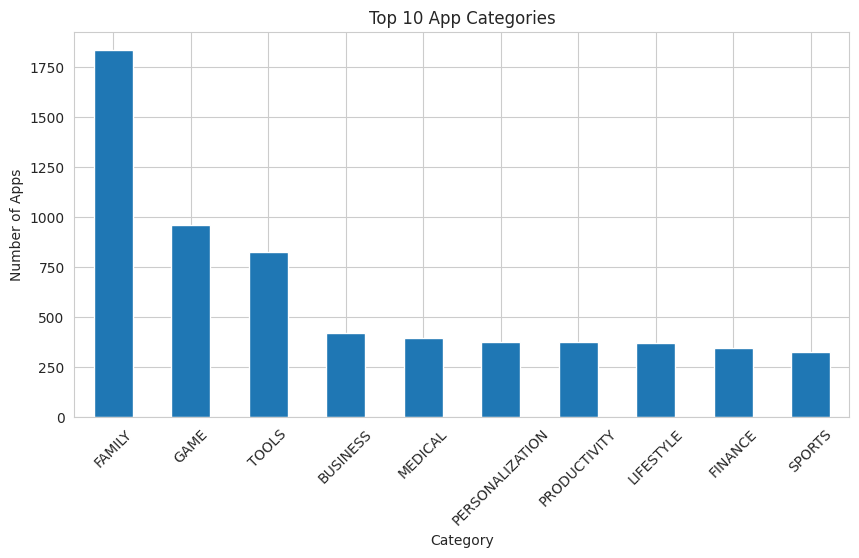

In [64]:
df["Category"].value_counts().head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 App Categories")
plt.xlabel("Category")
plt.ylabel("Number of Apps")
plt.xticks(rotation=45)
plt.show()

# Rating distribution

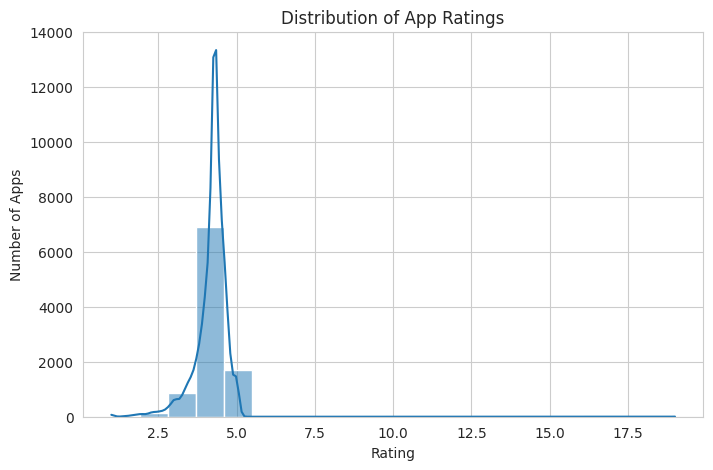

In [65]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Rating"],
    bins=20,
    kde=True
)

plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")
plt.show()

Free vs Paid apps

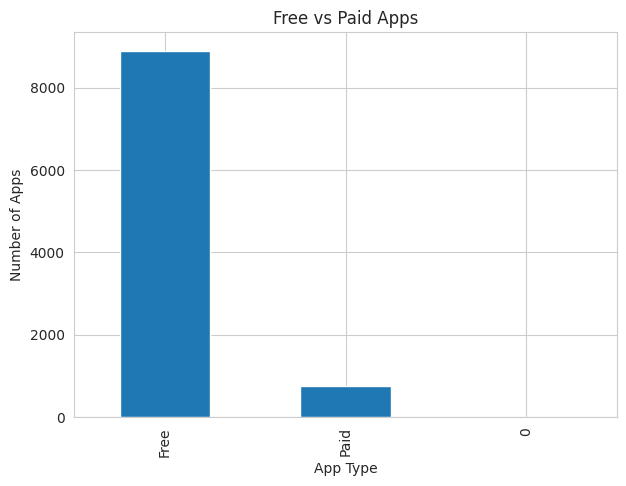

In [66]:
df["Type"].value_counts().plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Free vs Paid Apps")
plt.xlabel("App Type")
plt.ylabel("Number of Apps")
plt.show()

Top installed apps

In [67]:
top_apps = df.sort_values(
    "Installs",
    ascending=False
).head(10)

top_apps[["App", "Installs"]]

,App,Installs
3736,Google News,1.000000e+09
2554,Google+,1.000000e+09
1654,Subway Surfers,1.000000e+09
152,Google Play Books,1.000000e+09
3665,YouTube,1.000000e+09
2545,Instagram,1.000000e+09
3687,Google Play Movies & TV,1.000000e+09
2808,Google Photos,1.000000e+09
3127,Google Street View,1.000000e+09
865,Google Play Games,1.000000e+09


## Step 21 — Correlation Analysis
Select numerical columns:

In [68]:
numeric_columns = [
    "Rating",
    "Reviews",
    "Size_MB",
    "Installs",
    "Price"
]

corr = df[numeric_columns].corr()
corr

,Rating,Reviews,Size_MB,Installs,Price
Rating,1.000000,0.050207,0.045540,0.034307,-0.018662
Reviews,0.050207,1.000000,0.179321,0.625165,-0.007598
Size_MB,0.045540,0.179321,1.000000,0.134291,-0.022441
Installs,0.034307,0.625165,0.134291,1.000000,-0.009405
Price,-0.018662,-0.007598,-0.022441,-0.009405,1.000000


Heatmap

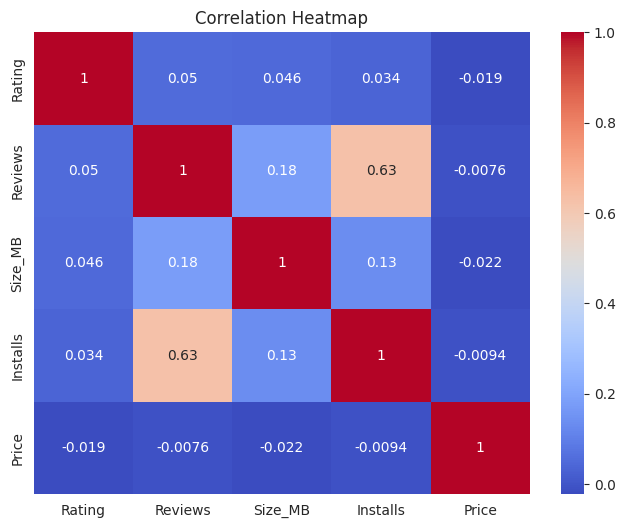

In [71]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

## Step 22 — Save Clean Dataset
This is important for your portfolio.

In [72]:
df.to_csv(
    "googleplaystore_cleaned.csv",
    index=False
)

In [73]:
files.download("googleplaystore_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##📊 Final Project Workflow

Your project can be presented as:

Google Play Store Dataset
          
          ↓

Data Loading
         
          ↓

Data Understanding
          
          ↓

Missing Value Analysis
         
          ↓

Duplicate Analysis
         
          ↓

Duplicate Removal
          
          ↓

Missing Value Handling
         
          ↓

Data Type Conversion
         
          ↓

Size / Installs / Price Cleaning
          
          ↓

Date Conversion
         
          ↓

Invalid Value Detection
        
          ↓

Feature Engineering
        
          ↓

Final Validation
         
          ↓

EDA & Visualization
        
          ↓

Clean Dataset